# Iterative scipy minimize tutorial: Open/IPOL idealized model

This notebook is an Open/IPOL version of the iterative scipy-minimize notebooks. It uses the shared `instruments.py` helpers as much as possible:

- `inst.read_csv` reads and formats the processed CSV data,
- `inst.generate_system_mueller_matrix` builds the system model from `system_dict`,
- `inst.parse_configuration`, `inst.logl`, `inst.model`, `inst.minimize_system_mueller_matrix`, and `inst.update_p0` handle the fitting workflow.

The fit uses rows where `OBS-MOD == "IPOL"` and `FILTER01 == "Open"`.

In [9]:
import copy
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd

# This notebook lives in scipy_minimize/notebooks/tutorials.
# If the kernel is running from this folder, ../../../ is the repository root.
REPO_ROOT = (Path.cwd() / "../../..").resolve()
if not (REPO_ROOT / "instruments.py").exists():
    cwd = Path.cwd().resolve()
    REPO_ROOT = next(
        (path for path in [cwd, *cwd.parents] if (path / "instruments.py").exists()),
        None,
    )

if REPO_ROOT is None:
    raise FileNotFoundError(
        "Could not find instruments.py. Start Jupyter from the tutorials folder or anywhere inside the vampires_calibration repository."
    )

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import instruments as inst

print(f"Using repository root: {REPO_ROOT}")

Using repository root: /home/rebeccaz/Github/vampires_calibration


## Paths

These are the only file paths needed for the tutorial. The final fit parameters and plot are saved next to this notebook.

In [10]:
tutorial_dir = REPO_ROOT / "scipy_minimize" / "notebooks" / "tutorials"
file_path = REPO_ROOT / "data" / "20230914_processed_table.csv"
starting_guess_file = tutorial_dir / "Open_IPOL_idealized_model_starting_guesses.txt"

output_filename = tutorial_dir / "Open_IPOL_idealized_model_iterative_fit.txt"
output_plot_filename = tutorial_dir / "Open_IPOL_idealized_model_iterative_fit.png"

print(f"Data file: {file_path}")
print(f"Starting guesses: {starting_guess_file}")
print(f"Output parameters: {output_filename}")

Data file: /home/rebeccaz/Github/vampires_calibration/data/20230914_processed_table.csv
Starting guesses: /home/rebeccaz/Github/vampires_calibration/scipy_minimize/notebooks/tutorials/Open_IPOL_idealized_model_starting_guesses.txt
Output parameters: /home/rebeccaz/Github/vampires_calibration/scipy_minimize/notebooks/tutorials/Open_IPOL_idealized_model_iterative_fit.txt


## Read the Open/IPOL data

The processed CSV already has the columns that `inst.read_csv` expects. Here we ask that helper for the Open-filter IPOL rows and let it return the interleaved `diff, sum, diff, sum, ...` arrays and the matching configuration list.

In [11]:
interleaved_values, interleaved_stds, configuration_list = inst.read_csv(
    file_path,
    obs_mode="IPOL",
    obs_filter="Open",
    flc_a_theta=0,
    flc_b_theta=45,
)

print(f"interleaved_values shape: {np.shape(interleaved_values)}")
print(f"interleaved_stds shape: {np.shape(interleaved_stds)}")
print(f"configuration_list length: {len(configuration_list)}")
print("First three parsed configurations:")
for config in configuration_list[:3]:
    print(config)

interleaved_values shape: (320,)
interleaved_stds shape: (320,)
configuration_list length: 160
First three parsed configurations:
{'hwp': {'theta': 0.0}, 'image_rotator': {'theta': 45.0}, 'flc': {'theta': 0}}
{'hwp': {'theta': 0.0}, 'image_rotator': {'theta': 45.0}, 'flc': {'theta': 45}}
{'hwp': {'theta': 0.0}, 'image_rotator': {'theta': 57.5}, 'flc': {'theta': 0}}


## Starting guesses

The starting guess file uses the same nested JSON-in-a-`.txt` format as the other iterative scipy-minimize notebooks.

In [12]:
with open(starting_guess_file, "r") as f:
    p0 = json.load(f)

initial_p0 = copy.deepcopy(p0)

print(json.dumps(p0, indent=4))

{
    "dichroic": {
        "phi": 0.0,
        "epsilon": 0.0,
        "theta": 0.0
    },
    "flc": {
        "phi": 3.141592653589793,
        "delta_theta": 0.0
    },
    "optics": {
        "phi": 0.0,
        "epsilon": 0.0,
        "theta": 0.0
    },
    "image_rotator": {
        "phi": 3.141592653589793,
        "delta_theta": 0.0
    },
    "hwp": {
        "phi": 3.141592653589793,
        "delta_theta": 0.0
    },
    "lp": {
        "theta": 0.0
    }
}


## Define the system model

This follows the same pattern as the original scipy-minimize notebooks: read each parameter out of `p0`, set the fixed Wollaston/EM-gain transmission ratio, then build `system_dict` inline.

In [13]:
theta_pol = p0["lp"]["theta"]
delta_HWP = p0["hwp"]["phi"]
offset_HWP = p0["hwp"]["delta_theta"]
delta_derot = p0["image_rotator"]["phi"]
offset_derot = p0["image_rotator"]["delta_theta"]
delta_opts = p0["optics"]["phi"]
epsilon_opts = p0["optics"]["epsilon"]
rot_opts = p0["optics"]["theta"]
delta_dichroic = p0["dichroic"]["phi"]
epsilon_dichroic = p0["dichroic"]["epsilon"]
rot_dichroic = p0["dichroic"]["theta"]
delta_FLC = p0["flc"]["phi"]
rot_FLC = p0["flc"]["delta_theta"]

# Fixed setting for this idealized tutorial.
em_gain = 1.0

# NOTE: Components must be listed downstream to upstream.
system_dict = {
    "components": {
        "wollaston": {
            "type": "wollaston_prism_function",
            "properties": {"beam": "o", "transmission_ratio": em_gain},
        },
        "dichroic": {
            "type": "diattenuator_retarder_function",
            "properties": {
                "phi": delta_dichroic,
                "epsilon": epsilon_dichroic,
                "theta": rot_dichroic,
            },
        },
        "flc": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_FLC, "theta": 0, "delta_theta": rot_FLC},
        },
        "optics": {
            "type": "diattenuator_retarder_function",
            "properties": {
                "phi": delta_opts,
                "epsilon": epsilon_opts,
                "theta": rot_opts,
            },
        },
        "image_rotator": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_derot, "theta": 0, "delta_theta": offset_derot},
        },
        "hwp": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_HWP, "theta": 0, "delta_theta": offset_HWP},
        },
        "lp": {
            "type": "general_linear_polarizer_function_with_theta",
            "properties": {"theta": theta_pol},
        },
    }
}

system_mm = inst.generate_system_mueller_matrix(system_dict)
p0_values, p0_keywords = inst.parse_configuration(p0)
s_in = np.array([1, 0, 0, 0])

## Bounds

The bounds list must stay in the same order as `inst.parse_configuration(p0)`.

In [14]:
bounds = [
    (-2 * np.pi, 2 * np.pi),  # dichroic phi
    (0, 1),  # dichroic epsilon
    (-90, 90),  # dichroic theta
    (0.4 * 2 * np.pi, 0.6 * 2 * np.pi),  # FLC phi
    (-5, 5),  # FLC delta_theta
    (-2 * np.pi, 2 * np.pi),  # optics phi
    (0, 1),  # optics epsilon
    (-90, 90),  # optics theta
    (0, np.pi),  # image rotator phi
    (-1, 1),  # image rotator delta_theta / IMR offset angle
    (0, np.pi),  # HWP phi
    (-5, 5),  # HWP delta_theta
    (-5, 5),  # LP theta
]

## Check the starting model

Initial logl value: 4801.621672674473


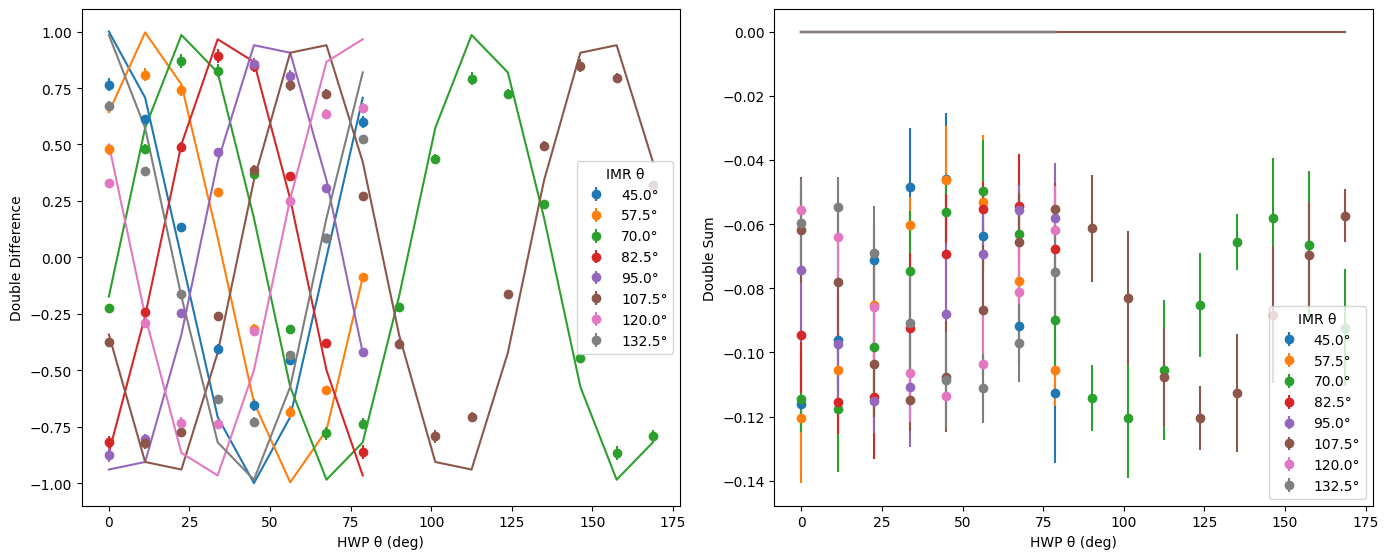

In [15]:
initial_logl = inst.logl(
    p0_values,
    p0_keywords,
    system_mm,
    interleaved_values,
    interleaved_stds,
    configuration_list,
    s_in=s_in,
    logl_function=None,
    process_dataset=inst.process_dataset,
    process_errors=inst.process_errors,
    process_model=inst.process_model,
)
print("Initial logl value:", initial_logl)

initial_model = inst.model(
    p0_values,
    p0_keywords,
    system_mm,
    configuration_list,
    process_model=inst.process_model,
)
inst.plot_data_and_model(interleaved_values, interleaved_stds, initial_model, configuration_list)

## Run the iterative scipy minimize fit

Before p0: {'dichroic': {'phi': 0.0, 'epsilon': 0.0, 'theta': 0.0}, 'flc': {'phi': 3.141592653589793, 'delta_theta': 0.0}, 'optics': {'phi': 0.0, 'epsilon': 0.0, 'theta': 0.0}, 'image_rotator': {'phi': 3.141592653589793, 'delta_theta': 0.0}, 'hwp': {'phi': 3.141592653589793, 'delta_theta': 0.0}, 'lp': {'theta': 0.0}}
Iteration #: 1
logl_value: 314.30961458052855
Best Fit Parameters: [-0.03034589  0.08463276 -0.19673148  3.21591375  0.01984567 -0.05339861
  0.          0.10959362  2.38583768 -0.0359478   2.99689337  0.04528527
 -0.03217545]


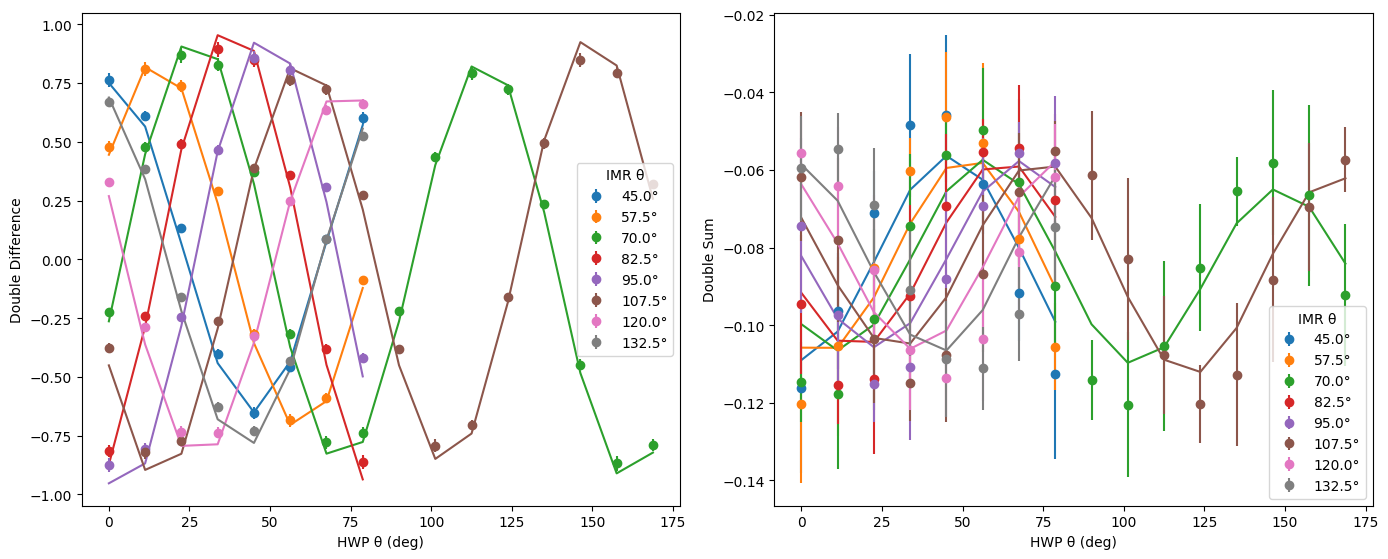

After p0: {'dichroic': {'phi': -0.03034588502486278, 'epsilon': 0.08463276189206477, 'theta': -0.1967314789249341}, 'flc': {'phi': 3.2159137500653614, 'delta_theta': 0.019845669134325825}, 'optics': {'phi': -0.05339860561022845, 'epsilon': 0.0, 'theta': 0.10959362318611324}, 'image_rotator': {'phi': 2.3858376757651114, 'delta_theta': -0.03594779858789993}, 'hwp': {'phi': 2.996893373462901, 'delta_theta': 0.04528526864519691}, 'lp': {'theta': -0.0321754479674799}}
Before p0: {'dichroic': {'phi': -0.03034588502486278, 'epsilon': 0.08463276189206477, 'theta': -0.1967314789249341}, 'flc': {'phi': 3.2159137500653614, 'delta_theta': 0.019845669134325825}, 'optics': {'phi': -0.05339860561022845, 'epsilon': 0.0, 'theta': 0.10959362318611324}, 'image_rotator': {'phi': 2.3858376757651114, 'delta_theta': -0.03594779858789993}, 'hwp': {'phi': 2.996893373462901, 'delta_theta': 0.04528526864519691}, 'lp': {'theta': -0.0321754479674799}}
Iteration #: 2
logl_value: 252.14543149623194
Best Fit Paramete

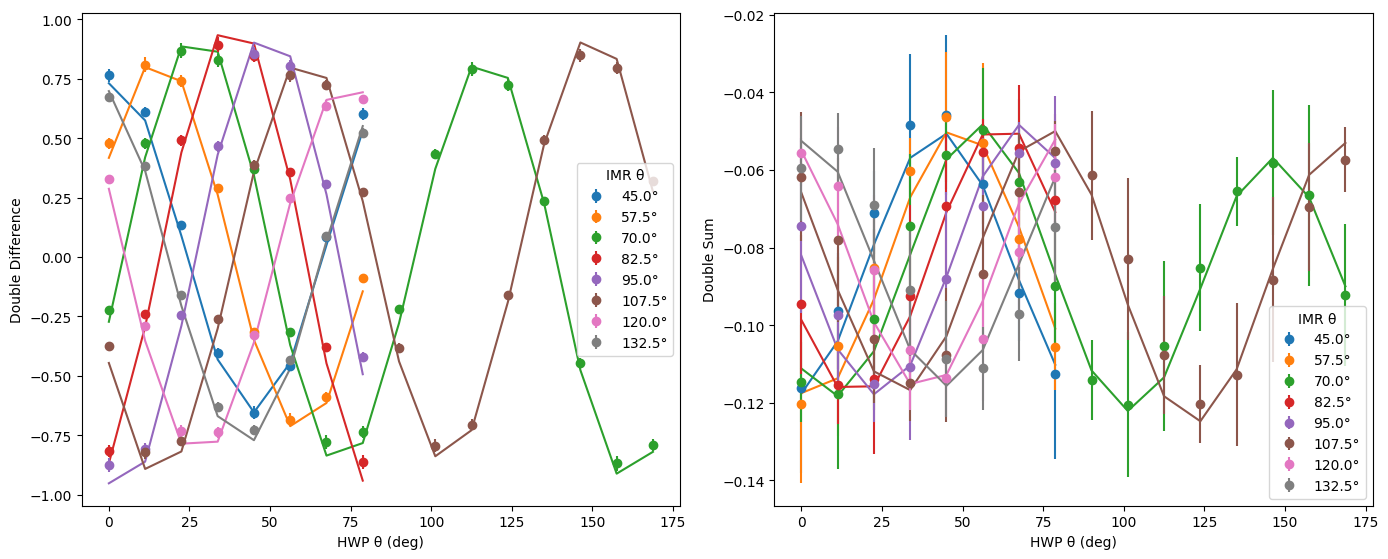

After p0: {'dichroic': {'phi': 0.15621511784395148, 'epsilon': 0.13351952100850972, 'theta': -24.60241002625736}, 'flc': {'phi': 3.470296659412739, 'delta_theta': -1.0449933321701481}, 'optics': {'phi': 0.5296490734069645, 'epsilon': 0.0004802687510170962, 'theta': -7.846301974443389}, 'image_rotator': {'phi': 2.3828925693461285, 'delta_theta': 0.9890286181904102}, 'hwp': {'phi': 3.000300064649199, 'delta_theta': -0.12286421935163061}, 'lp': {'theta': -1.6854753384844008}}
Before p0: {'dichroic': {'phi': 0.15621511784395148, 'epsilon': 0.13351952100850972, 'theta': -24.60241002625736}, 'flc': {'phi': 3.470296659412739, 'delta_theta': -1.0449933321701481}, 'optics': {'phi': 0.5296490734069645, 'epsilon': 0.0004802687510170962, 'theta': -7.846301974443389}, 'image_rotator': {'phi': 2.3828925693461285, 'delta_theta': 0.9890286181904102}, 'hwp': {'phi': 3.000300064649199, 'delta_theta': -0.12286421935163061}, 'lp': {'theta': -1.6854753384844008}}
Iteration #: 3
logl_value: 182.587498313643

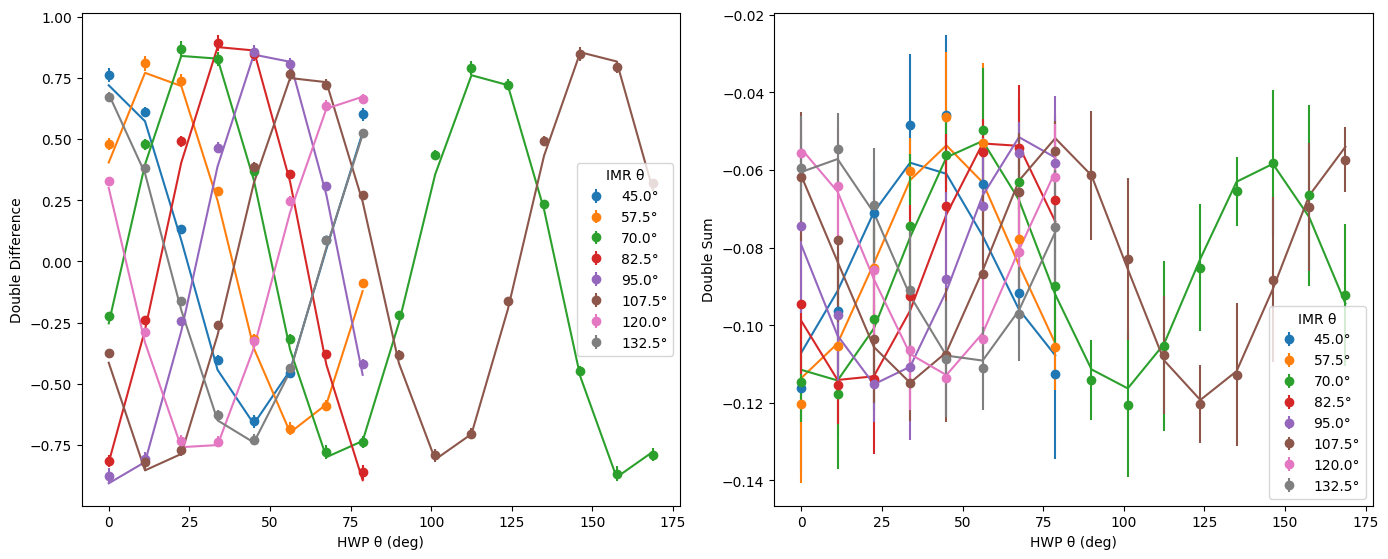

After p0: {'dichroic': {'phi': 0.08236645697143175, 'epsilon': 0.33990058613531726, 'theta': -37.61751672773647}, 'flc': {'phi': 3.3819368260601053, 'delta_theta': -0.5290912694356313}, 'optics': {'phi': 0.6465671566798483, 'epsilon': 5.506642970288007e-07, 'theta': -2.194364207433849}, 'image_rotator': {'phi': 2.4197259262094626, 'delta_theta': 0.6416059608205926}, 'hwp': {'phi': 2.987863648508286, 'delta_theta': -0.3776738581120216}, 'lp': {'theta': 0.17846180667552236}}
Before p0: {'dichroic': {'phi': 0.08236645697143175, 'epsilon': 0.33990058613531726, 'theta': -37.61751672773647}, 'flc': {'phi': 3.3819368260601053, 'delta_theta': -0.5290912694356313}, 'optics': {'phi': 0.6465671566798483, 'epsilon': 5.506642970288007e-07, 'theta': -2.194364207433849}, 'image_rotator': {'phi': 2.4197259262094626, 'delta_theta': 0.6416059608205926}, 'hwp': {'phi': 2.987863648508286, 'delta_theta': -0.3776738581120216}, 'lp': {'theta': 0.17846180667552236}}
Iteration #: 4
logl_value: 182.291956553634

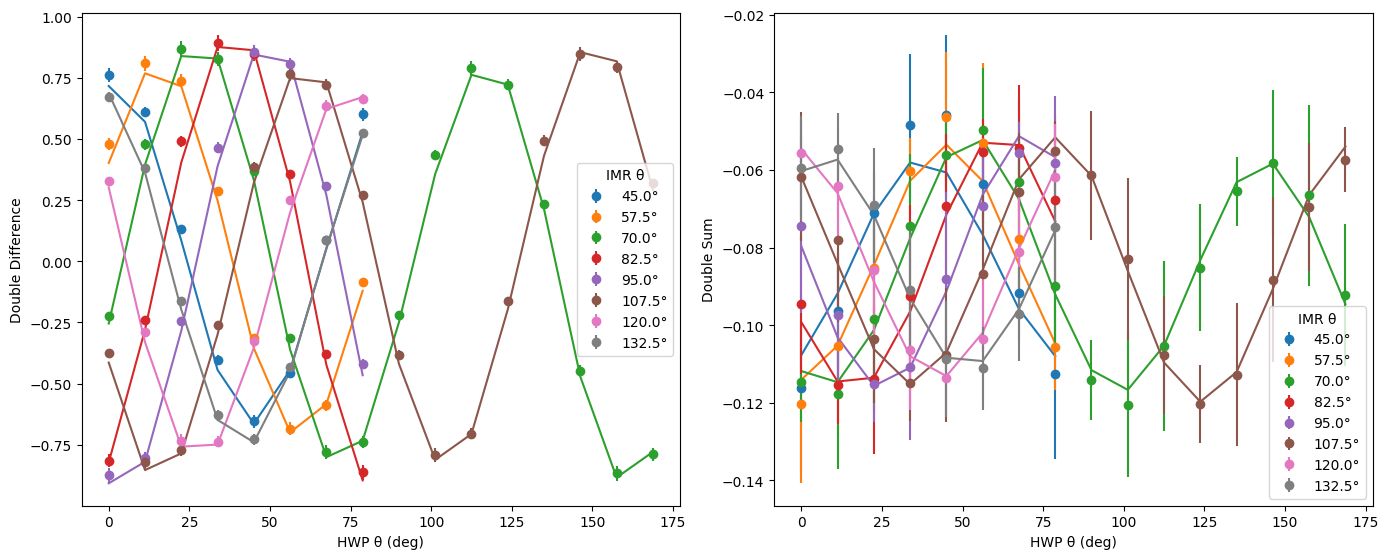

After p0: {'dichroic': {'phi': 0.08108243688031885, 'epsilon': 0.3379208350442595, 'theta': -37.55827303599865}, 'flc': {'phi': 3.3856068587656383, 'delta_theta': -1.1351990427821335}, 'optics': {'phi': 0.6411279102037315, 'epsilon': 2.9873936634672166e-06, 'theta': -3.6582407798504617}, 'image_rotator': {'phi': 2.418631003637734, 'delta_theta': -0.44931429752125074}, 'hwp': {'phi': 2.988703503317028, 'delta_theta': -0.7415326317221167}, 'lp': {'theta': 0.41659262007986875}}
Before p0: {'dichroic': {'phi': 0.08108243688031885, 'epsilon': 0.3379208350442595, 'theta': -37.55827303599865}, 'flc': {'phi': 3.3856068587656383, 'delta_theta': -1.1351990427821335}, 'optics': {'phi': 0.6411279102037315, 'epsilon': 2.9873936634672166e-06, 'theta': -3.6582407798504617}, 'image_rotator': {'phi': 2.418631003637734, 'delta_theta': -0.44931429752125074}, 'hwp': {'phi': 2.988703503317028, 'delta_theta': -0.7415326317221167}, 'lp': {'theta': 0.41659262007986875}}
Iteration #: 5
logl_value: 182.25737451

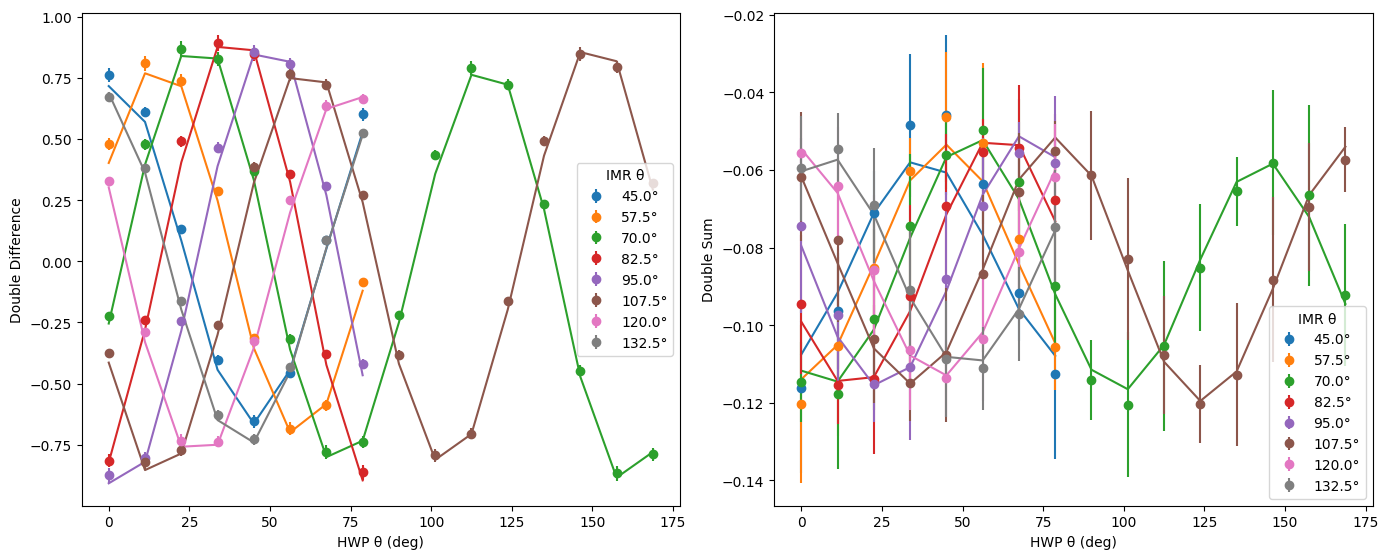

After p0: {'dichroic': {'phi': 0.07996784176276003, 'epsilon': 0.3378596990758612, 'theta': -37.56463965169125}, 'flc': {'phi': 3.3836506821809316, 'delta_theta': -1.189229146741273}, 'optics': {'phi': 0.6405125236307918, 'epsilon': 0.0, 'theta': -3.7895444437174604}, 'image_rotator': {'phi': 2.4188670651296036, 'delta_theta': -0.5502276555393633}, 'hwp': {'phi': 2.988263179011656, 'delta_theta': -0.78537923460761}, 'lp': {'theta': 0.38504635610148497}}
Saved fit parameters to: /home/rebeccaz/Github/vampires_calibration/scipy_minimize/notebooks/tutorials/Open_IPOL_idealized_model_iterative_fit.txt


In [16]:
convergence_fraction = 0.001
max_iterations = 50

iteration = 1
previous_logl_value = 1000000
new_logl_value = 0

while (
    abs(previous_logl_value - new_logl_value)
    > convergence_fraction * abs(previous_logl_value)
    and iteration <= max_iterations
):
    print("Before p0:", p0)
    if iteration > 1:
        previous_logl_value = new_logl_value

    result, new_logl_value = inst.minimize_system_mueller_matrix(
        p0,
        system_mm,
        interleaved_values,
        interleaved_stds,
        configuration_list,
        s_in=s_in,
        process_dataset=inst.process_dataset,
        process_errors=inst.process_errors,
        process_model=inst.process_model,
        bounds=bounds,
    )

    print("Iteration #:", iteration)
    print("logl_value:", new_logl_value)
    print("Best Fit Parameters:", result.x)

    updated_system_mm = inst.update_system_mm(result.x, p0_keywords, system_mm)
    model = inst.model(
        result.x,
        p0_keywords,
        updated_system_mm,
        configuration_list,
        process_model=inst.process_model,
    )

    inst.plot_data_and_model(
        interleaved_values,
        interleaved_stds,
        model,
        configuration_list,
        save_path=output_plot_filename,
    )

    inst.update_p0(p0, result.x)
    print("After p0:", p0)

    with open(output_filename, "w") as f:
        json.dump(p0, f, indent=4)

    iteration += 1

if iteration > max_iterations:
    print(f"Stopped after max_iterations={max_iterations}; inspect the last saved fit before using it.")

print(f"Saved fit parameters to: {output_filename}")

## Fit summary table

In [ ]:
starting_values, starting_keywords = inst.parse_configuration(initial_p0)
fit_values, fit_keywords = inst.parse_configuration(p0)

summary_rows = []
for keyword, start, fit, bound in zip(fit_keywords, starting_values, fit_values, bounds):
    component, parameter = keyword
    lower_bound, upper_bound = bound
    summary_rows.append(
        {
            "component": component,
            "parameter": parameter,
            "start": start,
            "fit": fit,
            "fit_minus_start": fit - start,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
        }
    )

fit_summary = pd.DataFrame(summary_rows)
fit_summary

,component,parameter,start,fit,fit_minus_start,lower_bound,upper_bound
0,dichroic,phi,0.000000,0.079968,0.079968,-6.283185,6.283185
1,dichroic,epsilon,0.000000,0.337860,0.337860,0.000000,1.000000
2,dichroic,theta,0.000000,-37.564640,-37.564640,-90.000000,90.000000
3,flc,phi,3.141593,3.383651,0.242058,2.513274,3.769911
4,flc,delta_theta,0.000000,-1.189229,-1.189229,-5.000000,5.000000
5,optics,phi,0.000000,0.640513,0.640513,-6.283185,6.283185
6,optics,epsilon,0.000000,0.000000,0.000000,0.000000,1.000000
7,optics,theta,0.000000,-3.789544,-3.789544,-90.000000,90.000000
8,image_rotator,phi,3.141593,2.418867,-0.722726,0.000000,3.141593
9,image_rotator,delta_theta,0.000000,-0.550228,-0.550228,-1.000000,1.000000
